In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = r"c:\Users\santi\OneDrive\Desktop\9no Cuatri\Base de Datos\Conjunto de datos para 2a. evaluación-20260813"

# 1. Carga
ruta_samsung = os.path.join(BASE_PATH, 'samsung.csv')
df_sam = pd.read_csv(ruta_samsung)

# 2. Exploración y Limpieza
# SOLUCIÓN: Agregamos dayfirst=True para que Pandas sepa que primero va el día
df_sam['Date'] = pd.to_datetime(df_sam['Date'], dayfirst=True)
df_sam = df_sam.sort_values('Date').reset_index(drop=True)

print("--- Información inicial ---")
df_sam.info()

# 3. Ingeniería de Variables
df_sam['Retorno_Diario'] = df_sam['Close'].pct_change() * 100
df_sam['Volatilidad_5d'] = df_sam['Retorno_Diario'].rolling(window=5).std()
df_sam.dropna(inplace=True)
df_sam.reset_index(drop=True, inplace=True)

print("\n--- Vista de los nuevos datos ---")
display(df_sam[['Date', 'Close', 'Volume', 'Retorno_Diario', 'Volatilidad_5d']].head())


--- Información inicial ---
<class 'pandas.DataFrame'>
RangeIndex: 2850 entries, 0 to 2849
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2850 non-null   datetime64[us]
 1   Close   2850 non-null   int64         
 2   Volume  2850 non-null   int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 66.9 KB

--- Vista de los nuevos datos ---


,Date,Close,Volume,Retorno_Diario,Volatilidad_5d
0,2008-01-09,10500,23865450,1.744186,2.032904
1,2008-01-10,10320,31551350,-1.714286,1.974025
2,2008-01-11,10320,23425150,0.000000,2.028308
3,2008-01-14,10500,22167000,1.744186,1.505918
4,2008-01-15,10640,40283950,1.333333,1.489103


In [7]:
# Seleccionamos las características a agrupar
features = ['Close', 'Volume', 'Retorno_Diario', 'Volatilidad_5d']
X = df_sam[features]

# Escalamiento de datos
scaler_kmeans = StandardScaler()
X_scaled = scaler_kmeans.fit_transform(X)

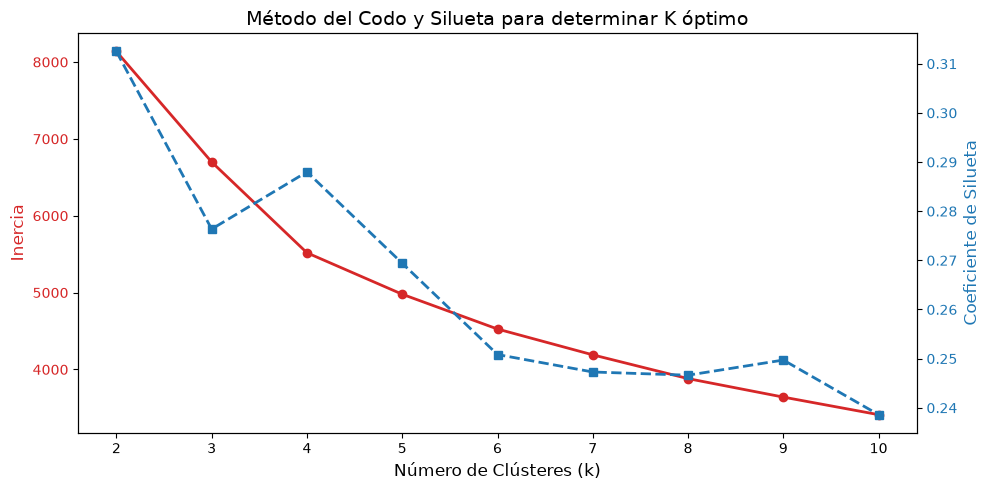

In [8]:
inercias = []
siluetas = []
rango_k = range(2, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)
    siluetas.append(silhouette_score(X_scaled, kmeans.labels_))

# Gráfica
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Número de Clústeres (k)', fontsize=12)
ax1.set_ylabel('Inercia', color=color, fontsize=12)
ax1.plot(rango_k, inercias, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Coeficiente de Silueta', color=color, fontsize=12)  
ax2.plot(rango_k, siluetas, marker='s', color=color, linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Método del Codo y Silueta para determinar K óptimo', fontsize=14)
fig.tight_layout()  
plt.show()

In [9]:
k_optimo = 3 

mejor_inercia = float('inf')
mejor_modelo = None

for n in [10, 30, 50]:
    temp_kmeans = KMeans(n_clusters=k_optimo, n_init=n, random_state=42)
    temp_kmeans.fit(X_scaled)
    if temp_kmeans.inertia_ < mejor_inercia:
        mejor_inercia = temp_kmeans.inertia_
        mejor_modelo = temp_kmeans

print(f"Mejor inercia obtenida: {mejor_inercia:.2f} con n_init={mejor_modelo.n_init}")

df_sam['Cluster'] = mejor_modelo.labels_

perfil_clusters = df_sam.groupby('Cluster')[features].mean()
print("\n--- Perfil Promedio de cada Clúster ---")
display(perfil_clusters)

Mejor inercia obtenida: 6699.09 con n_init=30

--- Perfil Promedio de cada Clúster ---


,Close,Volume,Retorno_Diario,Volatilidad_5d
Cluster,,,,
0,45814.927769,1.164475e+07,0.057813,1.476614
1,23438.868974,1.320519e+07,-0.005722,1.464557
2,15434.023179,2.840852e+07,0.290937,2.636271


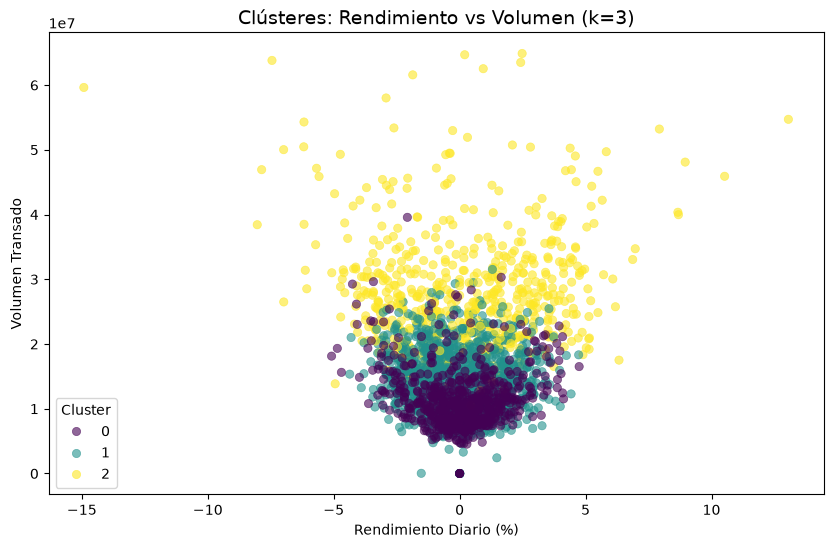

In [10]:
# 1. Gráfica 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sam, x='Retorno_Diario', y='Volume', hue='Cluster', 
                palette='viridis', alpha=0.6, edgecolor=None)
plt.title(f'Clústeres: Rendimiento vs Volumen (k={k_optimo})', fontsize=14)
plt.xlabel('Rendimiento Diario (%)')
plt.ylabel('Volumen Transado')
plt.show()

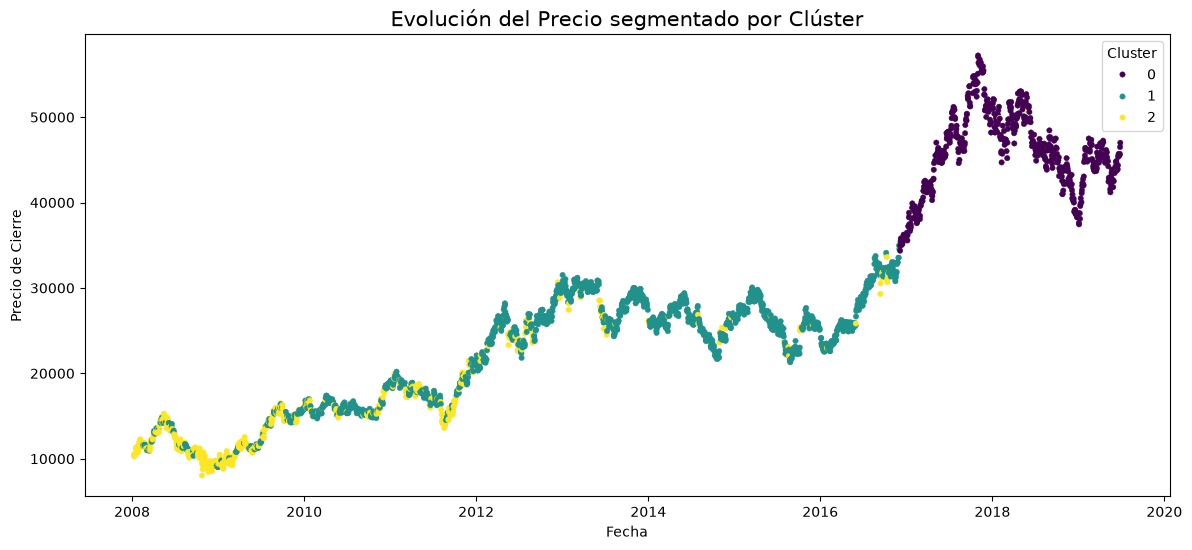

In [11]:
# 2. Serie de Tiempo
plt.figure(figsize=(14, 6))
sns.scatterplot(data=df_sam, x='Date', y='Close', hue='Cluster', 
                palette='viridis', s=15, edgecolor=None, legend='full')
plt.title('Evolución del Precio segmentado por Clúster', fontsize=15)
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre')
plt.show()

In [12]:
joblib.dump(mejor_modelo, 'modelo_samsung_kmeans.pkl')
joblib.dump(scaler_kmeans, 'scaler_samsung_kmeans.pkl')
print("✅ Modelo y Scaler guardados.")

✅ Modelo y Scaler guardados.
